# 02 - 仿真与渲染验证

运行 PyElastica 仿真，验证 3D 形状 → 2D 渲染的一致性。

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from elastica_env import (
    create_simulation, render_rod_as_image, render_to_binary,
    CAMERA_EYE, CAMERA_CENTER, CAMERA_UP,
)
from elastica.timestepper.symplectic_steppers import PositionVerlet
from elastica.timestepper import integrate

## 1. 单次仿真运行

In [2]:
# 修改驱动参数
driving_params = np.array([-0.003, 0.005])

final_time = 1.0
dt = 1e-4
total_steps = int(final_time / dt)

print(f'驱动参数: {driving_params}')
print(f'仿真: {final_time}s, dt={dt}, steps={total_steps}')

simulation, callback_data, _ = create_simulation(driving_params, total_steps, verbose=True)
timestepper = PositionVerlet()
integrate(timestepper, simulation, final_time, total_steps)

pos_3d = callback_data['position'][-1]
radius = callback_data['radius'][-1]
print(f'仿真完成。节点数: {pos_3d.shape[1]}')

驱动参数: [-0.003  0.005]
仿真: 1.0s, dt=0.0001, steps=10000


100%|██████████| 10000/10000 [00:00<00:00, 13466.19it/s]5125.27it/s]

Final time of simulation is :  0.9999999999998981
仿真完成。节点数: 31


## 2. 3D 形状可视化

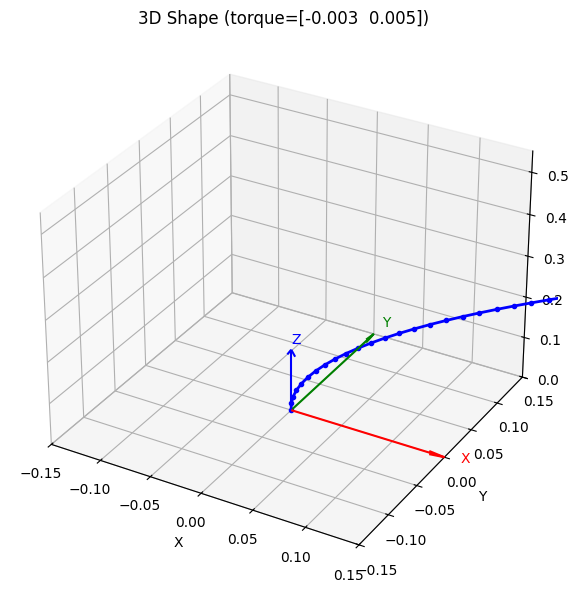

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pos_3d[0], pos_3d[1], pos_3d[2], 'b-o', linewidth=2, markersize=3)

# 坐标轴
origin = np.zeros(3)
length = 0.15
ax.quiver(*origin, length, 0, 0, color='r', arrow_length_ratio=0.1)
ax.quiver(*origin, 0, length, 0, color='g', arrow_length_ratio=0.1)
ax.quiver(*origin, 0, 0, length, color='b', arrow_length_ratio=0.1)
ax.text(length*1.1, 0, 0, 'X', color='r')
ax.text(0, length*1.1, 0, 'Y', color='g')
ax.text(0, 0, length*1.1, 'Z', color='b')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_xlim(-0.15, 0.15); ax.set_ylim(-0.15, 0.15); ax.set_zlim(0, 0.55)
ax.set_title(f'3D Shape (torque={driving_params})')
plt.tight_layout()
plt.show()

## 3. PyVista 渲染结果

2026-04-25 16:12:44.098 (   2.328s) [    7FA289DE7280]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


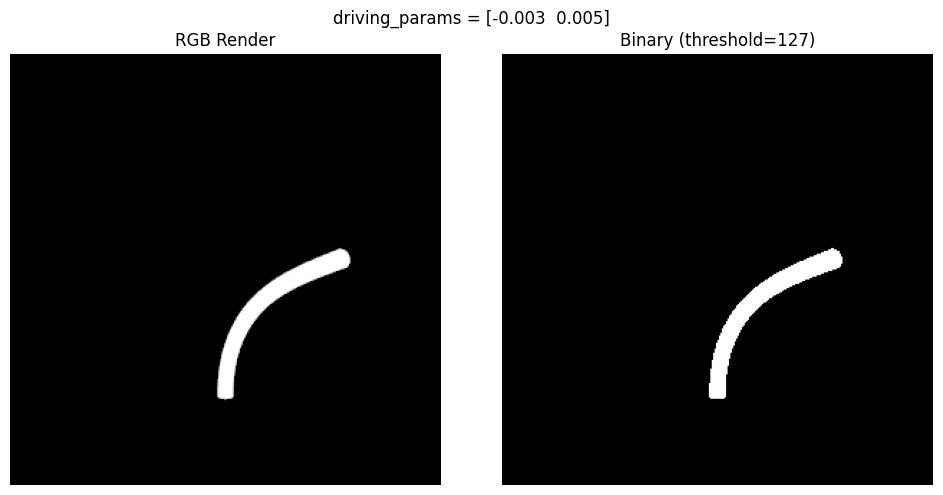

In [4]:
rgb_img = render_rod_as_image(pos_3d, radius, image_size=(300, 300))
binary_img = render_to_binary(pos_3d, radius, image_size=(300, 300))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(rgb_img)
ax1.set_title('RGB Render')
ax1.axis('off')

ax2.imshow(binary_img, cmap='gray', vmin=0, vmax=1)
ax2.set_title('Binary (threshold=127)')
ax2.axis('off')

plt.suptitle(f'driving_params = {driving_params}', fontsize=12)
plt.tight_layout()
plt.show()

## 4. 不同扭矩对比

100%|██████████| 10000/10000 [00:00<00:00, 17291.18it/s]


Final time of simulation is :  0.9999999999998981


100%|██████████| 10000/10000 [00:00<00:00, 19497.26it/s]


Final time of simulation is :  0.9999999999998981


100%|██████████| 10000/10000 [00:00<00:00, 18892.84it/s]


...

Final time of simulation is :  0.9999999999998981


100%|██████████| 10000/10000 [00:00<00:00, 24452.95it/s]


Final time of simulation is :  0.9999999999998981


100%|██████████| 10000/10000 [00:00<00:00, 23937.77it/s]


Final time of simulation is :  0.9999999999998981


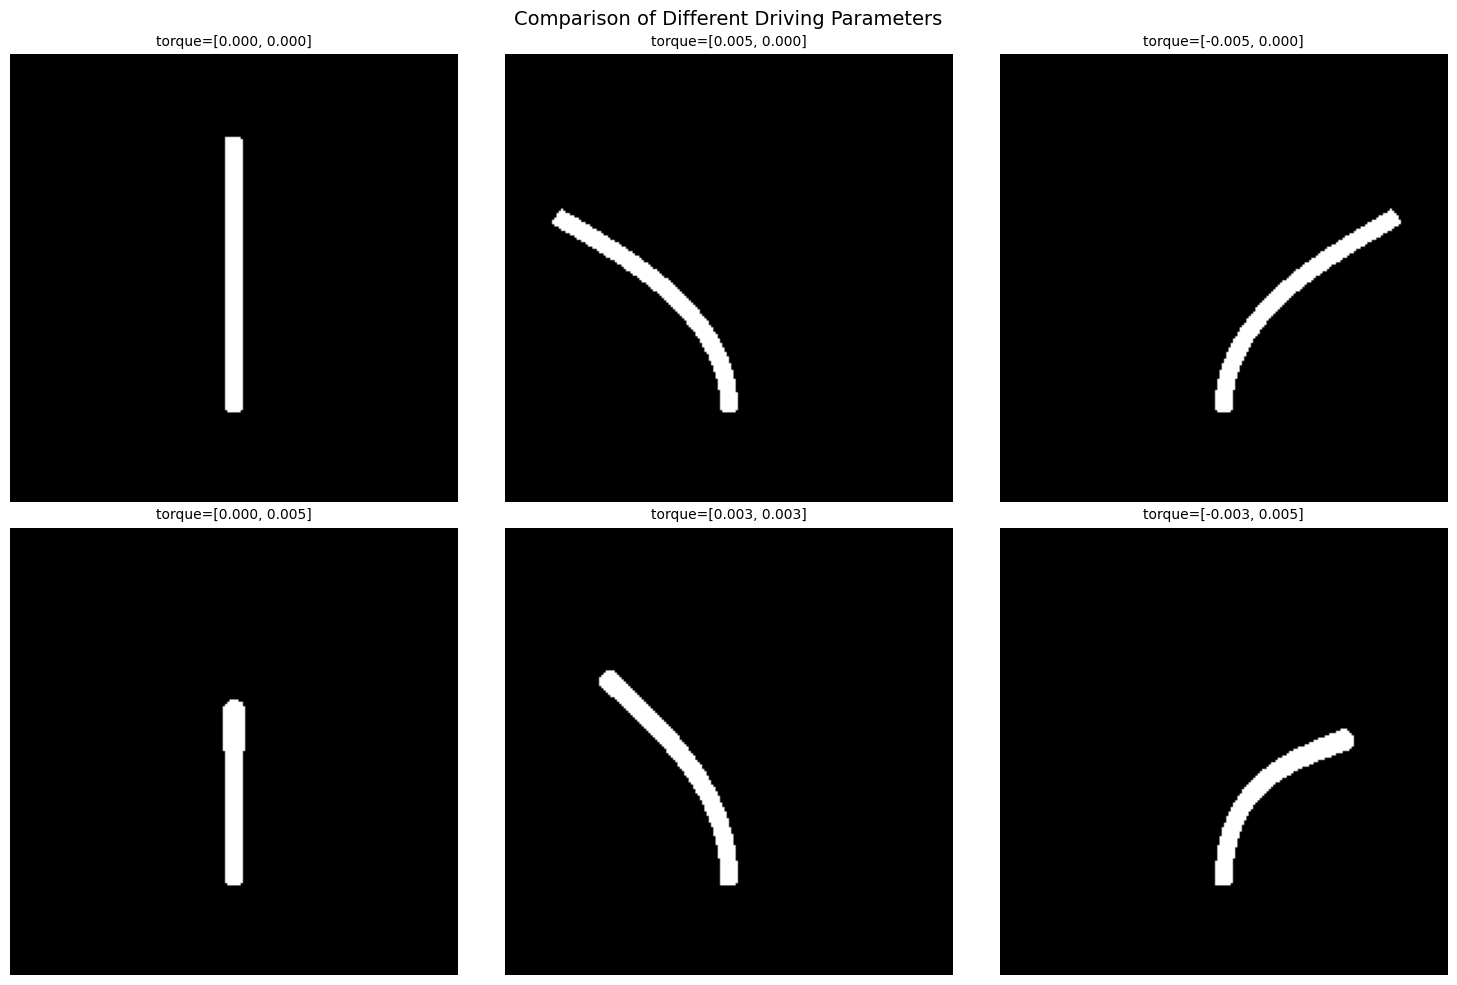

In [5]:
test_params_list = [
    np.array([0.0, 0.0]),
    np.array([0.005, 0.0]),
    np.array([-0.005, 0.0]),
    np.array([0.0, 0.005]),
    np.array([0.003, 0.003]),
    np.array([-0.003, 0.005]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, params in zip(axes.flat, test_params_list):
    sim, cb, _ = create_simulation(params, total_steps, verbose=False)
    integrate(PositionVerlet(), sim, final_time, total_steps)
    
    if cb['position']:
        p = cb['position'][-1]
        r = cb['radius'][-1]
        img = render_to_binary(p, r, image_size=(200, 200))
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    
    ax.set_title(f'torque=[{params[0]:.3f}, {params[1]:.3f}]', fontsize=10)
    ax.axis('off')

plt.suptitle('Comparison of Different Driving Parameters', fontsize=14)
plt.tight_layout()
plt.show()

## 5. 仿真时序快照（形变过程）

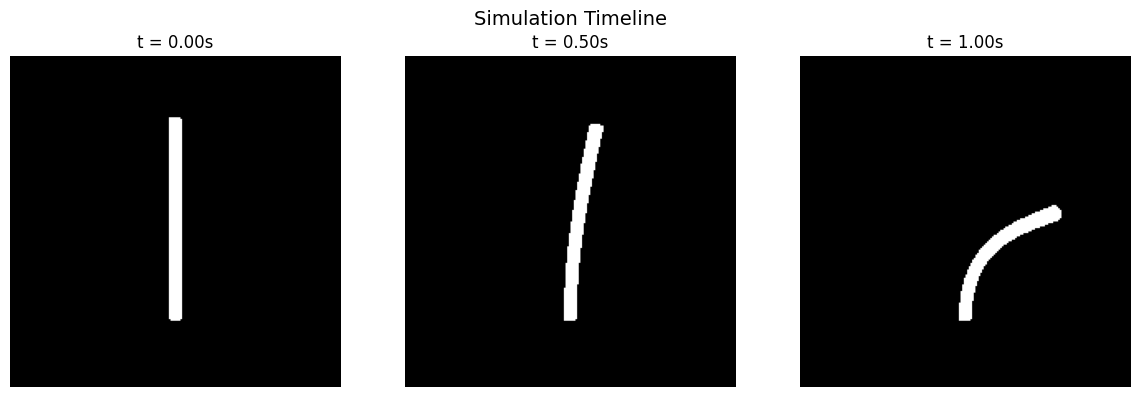

Simulating: 100%|██████████| 10000/10000 [00:19<00:00, 15125.27it/s]

In [6]:
# 取 callback 中记录的中间帧
if len(callback_data['position']) > 1:
    n_snapshots = min(6, len(callback_data['position']))
    step = max(1, len(callback_data['position']) // n_snapshots)
    indices = list(range(0, len(callback_data['position']), step))[:n_snapshots]

    fig, axes = plt.subplots(1, n_snapshots, figsize=(4 * n_snapshots, 4))
    if n_snapshots == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        p = callback_data['position'][idx]
        r = callback_data['radius'][idx]
        img = render_to_binary(p, r, image_size=(200, 200))
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        sim_time = idx * 5000 * dt  # step_skip=5000
        ax.set_title(f't = {sim_time:.2f}s')
        ax.axis('off')

    plt.suptitle('Simulation Timeline', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('只有 1 帧被记录（callback step_skip 太大或仿真太短）')